# Verify Robotics Hazards Dataset, Checkpoint, and Inference

Loads corridor images, folder/class metadata, ADVIS VAE-GAN checkpoint, reconstruction preview, threshold calibration, and subset inference. The test split is anomaly-only, so ranking metrics such as AUROC may be undefined.

In [1]:
from pathlib import Path
import sys

NOTEBOOK_DIR = Path.cwd() if Path.cwd().name == "notebooks" else Path.cwd() / "notebooks"
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

from verification_helpers import *

CONFIG_NAME = "corridor.yaml"
MAX_TRAIN_SAMPLES = 512
MAX_TEST_SAMPLES = 512

/Users/rashid/miniconda3/envs/pt/lib/python3.10/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


In [2]:
state = load_config_data(CONFIG_NAME)
cfg = state["cfg"]
project_root = state["project_root"]
device = state["device"]
train_dataset = state["train_dataset"]
test_dataset = state["test_dataset"]

print("config:", state["config_path"])
print("device:", device)
print("dataset:", cfg.data.name, cfg.data.category)
print("train:", state["summary"]["train"]["class_counts"])
print("test:", state["summary"]["test"]["class_counts"])
state["sample_records"](test_dataset, 5)

[+] Corridor dataset loaded
    Train normal: 45270
    Test anomalies: 84576
config: /Users/rashid/Nextcloud/RashidPHD/Codes/DistriMuSe/AD_MultiPointThreshold/configs/corridor.yaml
device: mps
dataset: Robotics_Hazards corridor
train: {'normal': 45270}
test: {'anomaly': 84576}


[{'path': '/Users/rashid/data/DS/AD/processed_corridor/test/box/006232_512_512.jpg',
  'file_name': '006232_512_512.jpg',
  'folder_name': 'box',
  'class_idx': 1,
  'class_name': 'anomaly'},
 {'path': '/Users/rashid/data/DS/AD/processed_corridor/test/box/006233_512_512.jpg',
  'file_name': '006233_512_512.jpg',
  'folder_name': 'box',
  'class_idx': 1,
  'class_name': 'anomaly'},
 {'path': '/Users/rashid/data/DS/AD/processed_corridor/test/box/006234_512_512.jpg',
  'file_name': '006234_512_512.jpg',
  'folder_name': 'box',
  'class_idx': 1,
  'class_name': 'anomaly'},
 {'path': '/Users/rashid/data/DS/AD/processed_corridor/test/box/006235_512_512.jpg',
  'file_name': '006235_512_512.jpg',
  'folder_name': 'box',
  'class_idx': 1,
  'class_name': 'anomaly'},
 {'path': '/Users/rashid/data/DS/AD/processed_corridor/test/box/006236_512_512.jpg',
  'file_name': '006236_512_512.jpg',
  'folder_name': 'box',
  'class_idx': 1,
  'class_name': 'anomaly'}]

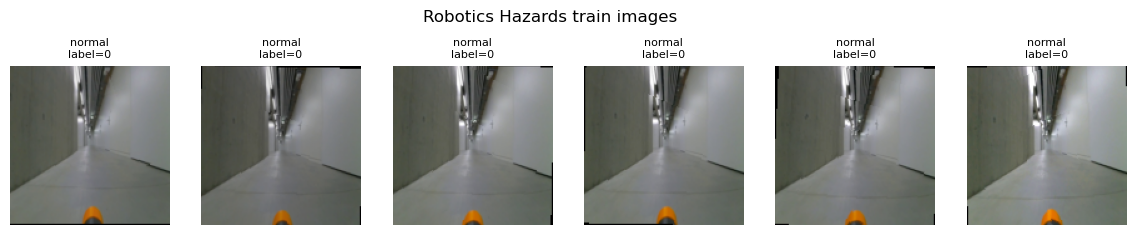

,path,file_name,folder_name,raw_label,label
0,/Users/rashid/data/DS/AD/processed_corridor/tr...,000187_512_512.jpg,normal,0,0
1,/Users/rashid/data/DS/AD/processed_corridor/tr...,000188_512_512.jpg,normal,0,0
2,/Users/rashid/data/DS/AD/processed_corridor/tr...,000189_512_512.jpg,normal,0,0
3,/Users/rashid/data/DS/AD/processed_corridor/tr...,000190_512_512.jpg,normal,0,0
4,/Users/rashid/data/DS/AD/processed_corridor/tr...,000191_512_512.jpg,normal,0,0
5,/Users/rashid/data/DS/AD/processed_corridor/tr...,000192_512_512.jpg,normal,0,0


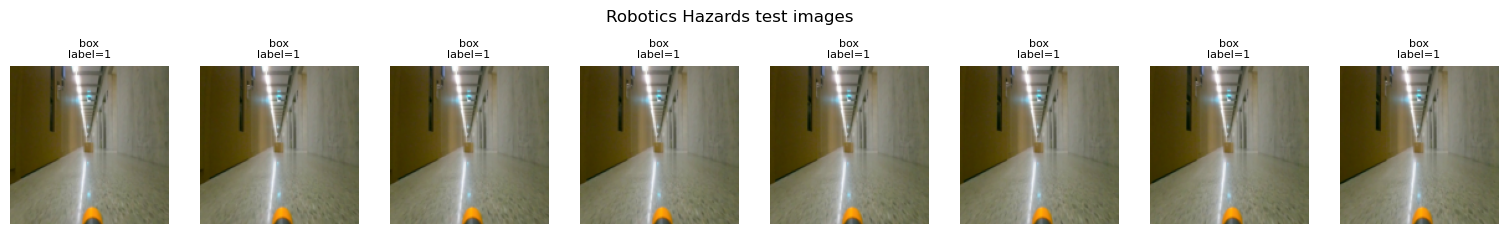

,path,file_name,folder_name,raw_label,label
0,/Users/rashid/data/DS/AD/processed_corridor/te...,006232_512_512.jpg,box,1,1
1,/Users/rashid/data/DS/AD/processed_corridor/te...,006233_512_512.jpg,box,1,1
2,/Users/rashid/data/DS/AD/processed_corridor/te...,006234_512_512.jpg,box,1,1
3,/Users/rashid/data/DS/AD/processed_corridor/te...,006235_512_512.jpg,box,1,1
4,/Users/rashid/data/DS/AD/processed_corridor/te...,006236_512_512.jpg,box,1,1
5,/Users/rashid/data/DS/AD/processed_corridor/te...,006237_512_512.jpg,box,1,1
6,/Users/rashid/data/DS/AD/processed_corridor/te...,006238_512_512.jpg,box,1,1
7,/Users/rashid/data/DS/AD/processed_corridor/te...,006239_512_512.jpg,box,1,1


In [3]:
display(show_samples(train_dataset, "Robotics Hazards train images", max_images=6))
display(show_samples(test_dataset, "Robotics Hazards test images", max_images=8))

In [4]:
checkpoint_path, encoder, decoder, discriminator = load_vaegan_model(cfg, device)
print("checkpoint:", checkpoint_path)
print("exists:", checkpoint_path.exists())
show_reconstructions(encoder, decoder, state["test_loader"], device, max_images=6)

checkpoint: /Users/rashid/Nextcloud/RashidPHD/Codes/DistriMuSe/AD_MultiPointThreshold/checkpoints/AD_Robotics_Hazards/model_corridor_64.pt
exists: True


/Users/rashid/Nextcloud/RashidPHD/Codes/DistriMuSe/AD_MultiPointThreshold/notebooks/verification_helpers.py:267: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [ ]:
training_history, training_artifacts = show_training_curves(project_root, cfg, checkpoint_path)
training_artifacts

No training loss history found for this dataset/model yet.


[]

In [6]:
metrics, results_df, threshold_model = run_subset_inference(
    cfg, encoder, decoder, discriminator,
    train_dataset, test_dataset,
    max_train_samples=MAX_TRAIN_SAMPLES,
    max_test_samples=MAX_TEST_SAMPLES,
)
display(metrics)
display(results_df.head())
display(results_df.groupby("folder_name")[["binary_label", "prediction"]].agg(["count", "mean"]))

Scoring (l1): 100%|██████████| 32/32 [00:01<00:00, 21.32it/s]


{'ranking_note': 'Only one class present in y_true. ROC AUC score is not defined in that case.',
 'precision': 0.9999999999999959,
 'recall': 0.47070312499999906,
 'f1': 0.6401062416994302,
 'tp': 241,
 'tn': 0,
 'fn': 271,
 'fp': 0}

,path,file_name,folder_name,class_idx,class_name,binary_label,prediction,score
0,/Users/rashid/data/DS/AD/processed_corridor/te...,006232_512_512.jpg,box,1,anomaly,1,0,0.056413
1,/Users/rashid/data/DS/AD/processed_corridor/te...,006233_512_512.jpg,box,1,anomaly,1,0,0.056752
2,/Users/rashid/data/DS/AD/processed_corridor/te...,006234_512_512.jpg,box,1,anomaly,1,0,0.057525
3,/Users/rashid/data/DS/AD/processed_corridor/te...,006235_512_512.jpg,box,1,anomaly,1,0,0.057713
4,/Users/rashid/data/DS/AD/processed_corridor/te...,006236_512_512.jpg,box,1,anomaly,1,0,0.057952


binary_label      prediction          
                   count mean      count      mean
folder_name                                       
box                  512  1.0        512  0.470703

In [7]:
output_dir = save_notebook_outputs(project_root, cfg.data.name, cfg.data.category, metrics, results_df, state["summary"])
print(output_dir)

/Users/rashid/Nextcloud/RashidPHD/Codes/DistriMuSe/AD_MultiPointThreshold/results/notebooks/Robotics_Hazards_corridor_verification
